In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import os
import shutil

# Source datasets
datasets = [
r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui",
r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\archive (5)",
r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\archive (6)"
]

# Destination dataset
merged_dataset = r"C:\Users\js731\Downloads\Merged_Dataset"

categories = ["notumor","glioma","pituitary","meningioma"]
splits = ["Training","Testing"]

# create merged dataset folders
for split in splits:
    for category in categories:
        os.makedirs(os.path.join(merged_dataset,split,category),exist_ok=True)

# copy images
for dataset in datasets:

    dataset_name = os.path.basename(dataset)   # important fix

    for split in splits:
        for category in categories:

            source_folder = os.path.join(dataset,split,category)
            destination_folder = os.path.join(merged_dataset,split,category)

            if os.path.exists(source_folder):

                for file in os.listdir(source_folder):

                    src = os.path.join(source_folder,file)

                    new_name = dataset_name + "_" + file

                    dst = os.path.join(destination_folder,new_name)

                    shutil.copy2(src,dst)

print("Merged dataset created successfully!")

Merged dataset created successfully!


In [4]:
dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\Merged_Dataset"
classes = ["notumor","glioma","pituitary","meningioma"]
splits = ["Training","Testing"]

In [5]:
data = []

for split in splits:
    for cls in classes:
        folder = os.path.join(dataset_path, split, cls)
        count = len(os.listdir(folder))
        
        data.append({
            "Dataset": split,
            "Class": cls,
            "Image_Count": count
        })

df = pd.DataFrame(data)
print(df)

    Dataset       Class  Image_Count
0  Training     notumor          875
1  Training      glioma         2433
2  Training   pituitary         1650
3  Training  meningioma         1512
4   Testing     notumor          618
5   Testing      glioma          888
6   Testing   pituitary          790
7   Testing  meningioma          704


In [6]:
total_distribution = df.groupby("Class")["Image_Count"].sum()
print(total_distribution)

Class
glioma        3321
meningioma    2216
notumor       1493
pituitary     2440
Name: Image_Count, dtype: int64


In [7]:
import os
from PIL import Image
import imagehash
from tqdm import tqdm

dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\Merged_Dataset"

hash_dict = {}
duplicates = []

# walk through dataset
for root, dirs, files in os.walk(dataset_path):
    
    for file in tqdm(files):
        
        if file.lower().endswith(('.png','.jpg','.jpeg')):
            
            file_path = os.path.join(root, file)
            
            try:
                img = Image.open(file_path).convert("L")
                
                # perceptual hash
                img_hash = imagehash.phash(img)
                
                if img_hash in hash_dict:
                    duplicates.append((file_path, hash_dict[img_hash]))
                else:
                    hash_dict[img_hash] = file_path
                    
            except Exception as e:
                print("Error:", file_path)

print("Total duplicates found:", len(duplicates))

0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 790/790 [00:01<00:00, 416.14it/s]
0it [00:00, ?it/s]
100%|██████████| 1650/1650 [00:03<00:00, 458.44it/s]

Total duplicates found: 0


In [8]:
removed = 0

for dup in duplicates:
    
    duplicate_image = dup[0]   # duplicate file path
    
    try:
        os.remove(duplicate_image)
        removed += 1
    except:
        print("Error removing:", duplicate_image)

print("Total duplicates removed:", removed)

Total duplicates removed: 0


In [9]:
import os

dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\Merged_Dataset"

total_images = 0

for root, dirs, files in os.walk(dataset_path):
    total_images += len(files)

print("Total images after duplicate removal:", total_images)

Total images after duplicate removal: 9470


In [10]:
import pandas as pd

classes = ["glioma","meningioma","notumor","pituitary"]

data = []

for cls in classes:
    
    folder = os.path.join(dataset_path,"Training",cls)
    
    count = len(os.listdir(folder))
    
    data.append([cls,count])

df = pd.DataFrame(data,columns=["Class","Image_Count"])

print(df)

        Class  Image_Count
0      glioma         2433
1  meningioma         1512
2     notumor          875
3   pituitary         1650


In [11]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_dataset = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\raw\Merged_Dataset"

new_dataset = r"C:\Users\js731\Downloads\brain_tumor_dataset_final"

classes = ["notumor","glioma","pituitary","meningioma"]

# create folder structure
for split in ["Training","Validation","Testing"]:
    for cls in classes:
        os.makedirs(os.path.join(new_dataset,split,cls),exist_ok=True)

for cls in classes:
    
    images = []
    
    # collect images from both folders
    for split in ["Training","Testing"]:
        folder = os.path.join(source_dataset,split,cls)
        
        for img in os.listdir(folder):
            images.append(os.path.join(folder,img))
    
    # 70% train
    train_imgs, temp_imgs = train_test_split(images,test_size=0.30,random_state=42)
    
    # 15% val + 15% test
    val_imgs, test_imgs = train_test_split(temp_imgs,test_size=0.50,random_state=42)

    # copy training
    for img in train_imgs:
        shutil.copy2(img, os.path.join(new_dataset,"Training",cls,os.path.basename(img)))

    # copy validation
    for img in val_imgs:
        shutil.copy2(img, os.path.join(new_dataset,"Validation",cls,os.path.basename(img)))

    # copy testing
    for img in test_imgs:
        shutil.copy2(img, os.path.join(new_dataset,"Testing",cls,os.path.basename(img)))

print("Dataset split into Train / Validation / Test successfully")

Dataset split into Train / Validation / Test successfully


In [12]:
import os
import pandas as pd

dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\brain_tumor_dataset_final"

splits = ["Training","Validation","Testing"]
classes = ["notumor","glioma","pituitary","meningioma"]

data = []

for split in splits:
    for cls in classes:
        
        folder = os.path.join(dataset_path, split, cls)
        
        if os.path.exists(folder):
            count = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        else:
            count = 0
        
        data.append({
            "Dataset": split,
            "Class": cls,
            "Image_Count": count
        })

df = pd.DataFrame(data)

print(df)

       Dataset       Class  Image_Count
0     Training     notumor         1045
1     Training      glioma         2324
2     Training   pituitary         1708
3     Training  meningioma         1551
4   Validation     notumor          224
5   Validation      glioma          498
6   Validation   pituitary          366
7   Validation  meningioma          332
8      Testing     notumor          224
9      Testing      glioma          499
10     Testing   pituitary          366
11     Testing  meningioma          333


In [15]:
total_distribution = df.groupby("Class")["Image_Count"].sum()

print(total_distribution)

Class
glioma        3321
meningioma    2216
notumor       1493
pituitary     2440
Name: Image_Count, dtype: int64


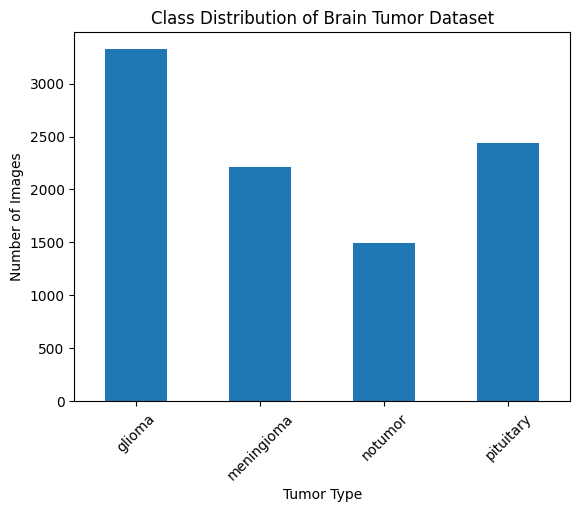

In [16]:
total_distribution.plot(kind="bar")

plt.title("Class Distribution of Brain Tumor Dataset")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

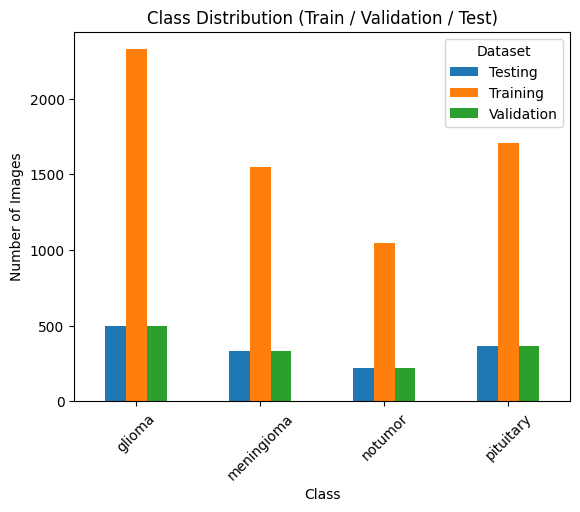

In [17]:
import matplotlib.pyplot as plt

pivot = df.pivot(index="Class",columns="Dataset",values="Image_Count")

pivot.plot(kind="bar")

plt.title("Class Distribution (Train / Validation / Test)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

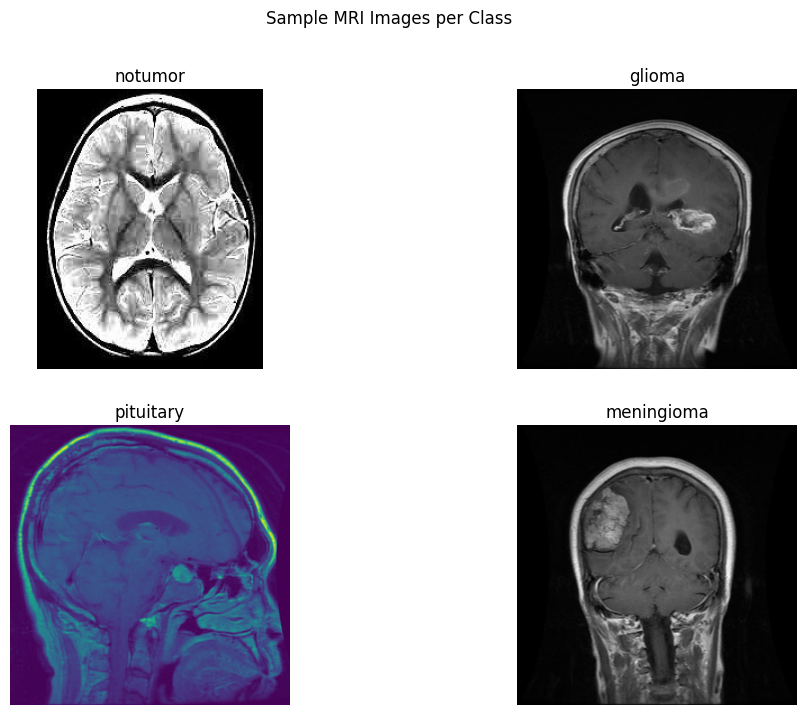

In [18]:
# Sample Image Visualization
import random
dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\brain_tumor_dataset_final"

classes = ["notumor","glioma","pituitary","meningioma"]
split = "Training"   

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    
    folder = os.path.join(dataset_path, split, cls)
    
    images = os.listdir(folder)
    
    sample_img = random.choice(images)
    
    img_path = os.path.join(folder, sample_img)
    
    img = Image.open(img_path)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample MRI Images per Class")
plt.show()

In [19]:
dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\brain_tumor_dataset_final"

splits = ["Training","Validation","Testing"]
classes = ["notumor","glioma","pituitary","meningioma"]

In [20]:
resolution_data = []

for split in splits:
    for cls in classes:
        
        folder = os.path.join(dataset_path, split, cls)
        
        for img_file in os.listdir(folder):
            
            img_path = os.path.join(folder, img_file)
            
            try:
                img = Image.open(img_path)
                width, height = img.size
                
                resolution_data.append({
                    "Dataset": split,
                    "Class": cls,
                    "Width": width,
                    "Height": height
                })
                
            except:
                print("Error reading:", img_path)

df_res = pd.DataFrame(resolution_data)

print(df_res.head())

    Dataset    Class  Width  Height
0  Training  notumor    200     252
1  Training  notumor    225     225
2  Training  notumor    442     442
3  Training  notumor    227     222
4  Training  notumor    428     417


In [21]:
print(df_res[["Width","Height"]].describe())

             Width       Height
count  9470.000000  9470.000000
mean    404.491658   405.868427
std     145.082870   143.330848
min     150.000000   167.000000
25%     224.000000   224.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1375.000000  1446.000000


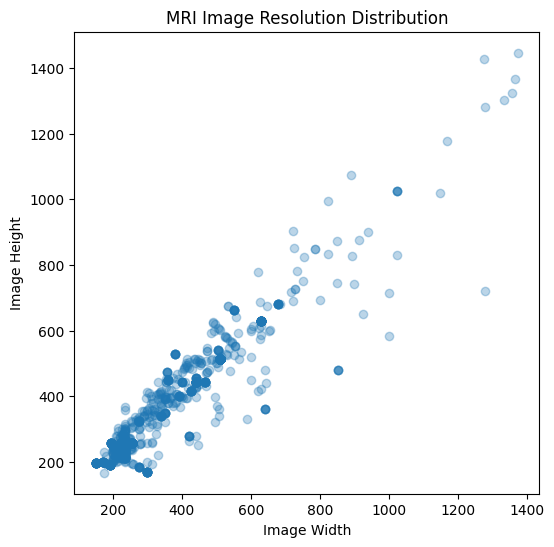

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(df_res["Width"], df_res["Height"], alpha=0.3)

plt.xlabel("Image Width")
plt.ylabel("Image Height")

plt.title("MRI Image Resolution Distribution")

plt.show()

In [23]:
resolution_counts = df_res.groupby(["Width","Height"]).size().sort_values(ascending=False)

print(resolution_counts.head(10))

Width  Height
512    512       5507
224    224       2637
225    225        193
630    630         41
236    236         34
256    256         33
200    252         29
442    442         28
150    198         28
228    221         26
dtype: int64


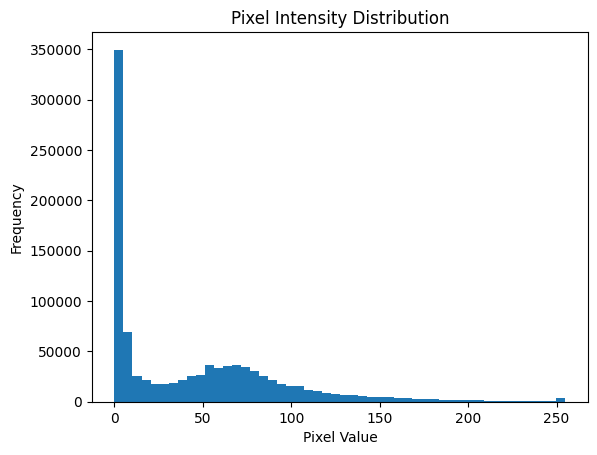

In [24]:
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

pixel_values = []

sample_size = 2000   # number of images to sample

all_images = []

for split in splits:
    for cls in classes:
        folder = os.path.join(dataset_path,split,cls)

        for img in os.listdir(folder):
            all_images.append(os.path.join(folder,img))

sample_images = random.sample(all_images, sample_size)

for path in sample_images:

    try:
        img = Image.open(path).convert("L")
        img_arr = np.array(img)

        pixels = img_arr.flatten()

        pixel_values.extend(np.random.choice(pixels,500))

    except:
        pass

plt.hist(pixel_values,bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

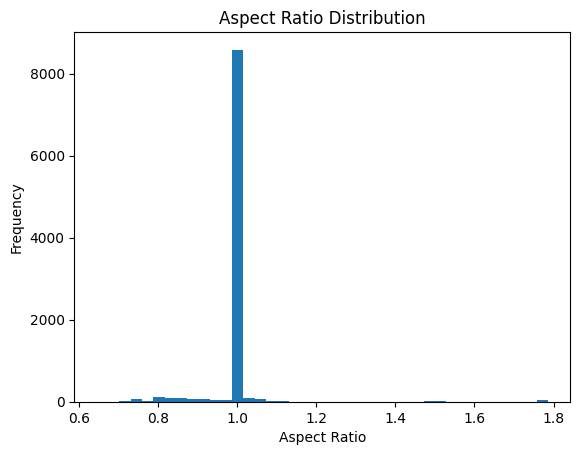

In [25]:
# Aspect Ratio Analysis
aspect_ratios = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:
                img = Image.open(path)

                w,h = img.size

                aspect_ratios.append(w/h)

            except:
                pass

plt.hist(aspect_ratios, bins=40)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

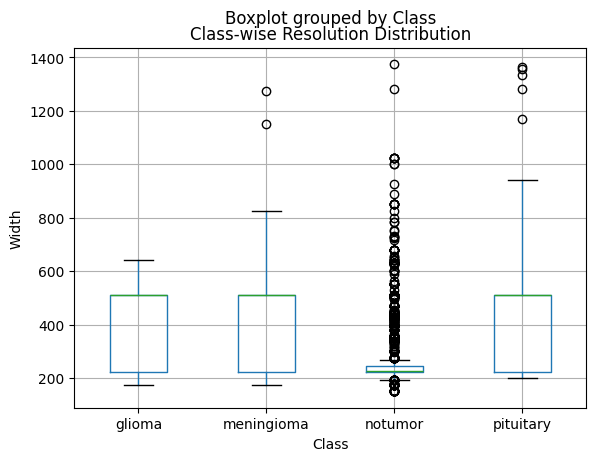

In [26]:
# Class-wise Resolution Distribution
import pandas as pd

resolution_data = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:
                img = Image.open(path)

                w,h = img.size

                resolution_data.append({
                    "Class":cls,
                    "Width":w,
                    "Height":h
                })

            except:
                pass

df = pd.DataFrame(resolution_data)

df.boxplot(column="Width",by="Class")

plt.title("Class-wise Resolution Distribution")
plt.ylabel("Width")

plt.show()

In [27]:
# Corrupted Image Detection
corrupted_images = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:
                img = Image.open(path)
                img.verify()

            except:
                corrupted_images.append(path)

print("Total corrupted images:", len(corrupted_images))

Total corrupted images: 0


In [29]:
# Tumor Size & Location Analysis
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\brain_tumor_dataset_final"

classes = ["glioma","meningioma","pituitary"]
splits = ["Training","Validation","Testing"]

tumor_data = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:

                img = cv2.imread(path,0)

                # threshold segmentation
                _,thresh = cv2.threshold(img,150,255,cv2.THRESH_BINARY)

                contours,_ = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

                if contours:

                    largest = max(contours,key=cv2.contourArea)

                    area = cv2.contourArea(largest)

                    x,y,w,h = cv2.boundingRect(largest)

                    cx = x + w/2
                    cy = y + h/2

                    tumor_data.append({
                        "Class":cls,
                        "Area":area,
                        "Center_X":cx,
                        "Center_Y":cy
                    })

            except:
                pass

df_tumor = pd.DataFrame(tumor_data)

print(df_tumor.head())

    Class    Area  Center_X  Center_Y
0  glioma  7881.0     177.0     223.0
1  glioma  1323.0     245.5     135.5
2  glioma   152.5     234.5      54.0
3  glioma  4084.0     258.0     139.5
4  glioma   361.0     124.0     365.0


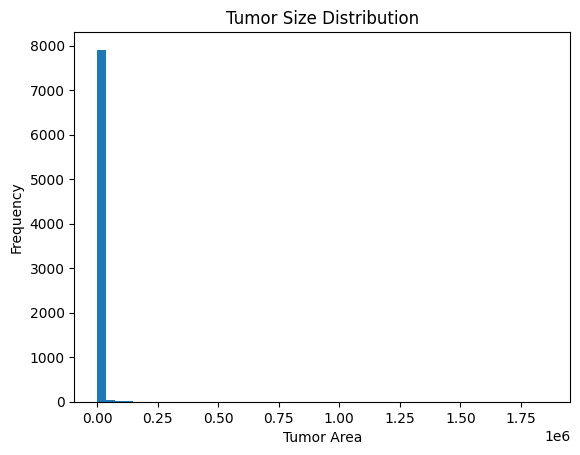

In [30]:
plt.hist(df_tumor["Area"],bins=50)

plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Area")
plt.ylabel("Frequency")

plt.show()

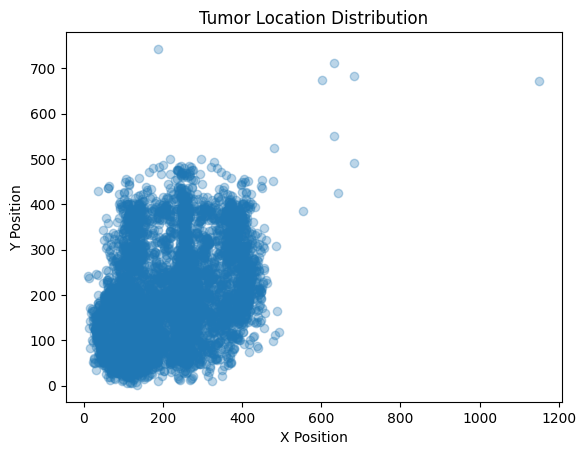

In [31]:
plt.scatter(df_tumor["Center_X"],df_tumor["Center_Y"],alpha=0.3)

plt.title("Tumor Location Distribution")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.show()

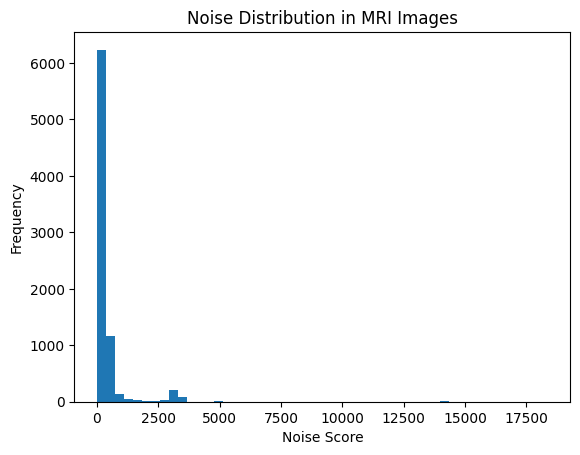

In [32]:
# Noise Analysis
noise_scores = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:

                img = cv2.imread(path,0)

                noise = cv2.Laplacian(img,cv2.CV_64F).var()

                noise_scores.append(noise)

            except:
                pass

plt.hist(noise_scores,bins=50)

plt.title("Noise Distribution in MRI Images")

plt.xlabel("Noise Score")
plt.ylabel("Frequency")

plt.show()

In [33]:
dataset_path = r"C:\Users\js731\Downloads\Brain-Tumor-Detection-XAI\data\brain_tumor_dataset_final"

splits = ["Training","Validation","Testing"]
classes = ["notumor","glioma","pituitary","meningioma"]

image_count = 0
widths = []
heights = []
aspect_ratios = []
pixel_samples = []
tumor_areas = []

for split in splits:
    for cls in classes:

        folder = os.path.join(dataset_path,split,cls)

        for img_file in os.listdir(folder):

            path = os.path.join(folder,img_file)

            try:
                img = Image.open(path)
                w,h = img.size

                widths.append(w)
                heights.append(h)

                aspect_ratios.append(w/h)

                # sample pixels
                gray = img.convert("L")
                arr = np.array(gray)

                sample = np.random.choice(arr.flatten(),200)
                pixel_samples.extend(sample)

                # tumor estimation (skip notumor)
                if cls!="notumor":

                    img_cv = cv2.imread(path,0)

                    _,th = cv2.threshold(img_cv,150,255,cv2.THRESH_BINARY)

                    contours,_ = cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

                    if contours:

                        largest = max(contours,key=cv2.contourArea)

                        tumor_areas.append(cv2.contourArea(largest))

                image_count+=1

            except:
                pass


print("\n====== DATASET SUMMARY ======\n")

print("Total Images :",image_count)

print("\nResolution Stats")
print("Min Width :",min(widths))
print("Max Width :",max(widths))
print("Mean Width :",np.mean(widths))

print("\nMin Height :",min(heights))
print("Max Height :",max(heights))
print("Mean Height :",np.mean(heights))

print("\nAspect Ratio Stats")
print("Mean Aspect Ratio :",np.mean(aspect_ratios))

print("\nPixel Intensity Stats")
print("Min Pixel :",np.min(pixel_samples))
print("Max Pixel :",np.max(pixel_samples))
print("Mean Pixel :",np.mean(pixel_samples))

print("\nTumor Size Stats")
print("Min Tumor Area :",np.min(tumor_areas))
print("Max Tumor Area :",np.max(tumor_areas))
print("Mean Tumor Area :",np.mean(tumor_areas))


====== DATASET SUMMARY ======

Total Images : 9470

Resolution Stats
Min Width : 150
Max Width : 1375
Mean Width : 404.49165786694823

Min Height : 167
Max Height : 1446
Mean Height : 405.8684266103485

Aspect Ratio Stats
Mean Aspect Ratio : 0.9963585398450567

Pixel Intensity Stats
Min Pixel : 0
Max Pixel : 255
Mean Pixel : 44.993422914466734

Tumor Size Stats
Min Tumor Area : 0.0
Max Tumor Area : 1860496.0
Mean Tumor Area : 3387.2930926413437
